# Qual é o melhor plano?

Você trabalha como analista para a empresa de telecomunicações Megaline. A empresa oferece aos clientes dois planos pré-pagos: Surf e Ultimate. O departamento comercial quer saber qual dos planos gera mais receita para ajustar o orçamento de publicidade.

Você vai realizar uma análise preliminar dos planos com base em uma pequena seleção de clientes. Você terá dados de 500 clientes da Megaline: que clientes são, de onde eles são, qual plano usam e o número de chamadas e mensagens realizadas em 2018. Seu trabalho é analisar o comportamento dos clientes e determinar qual plano pré-pago gera mais receita.

[Fornecemos alguns comentários para guiar sua linha de raciocínio enquanto você trabalha neste projeto. Entretanto, certifique-se de remover todos os comentários entre colchetes antes de enviar o projeto.]

[Antes de começar a análise dos dados, explique com suas próprias palavras o propósito do projeto e as ações que planeja realizar.]

[Tenha em mente que estudar, modificar e analisar dados é um processo iterativo. É normal retornar a etapas anteriores e corrigir/expandir algo para permitir as próximas etapas.]

## Inicialização

In [1]:
# Carregando todas as bibliotecas
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Carregue os dados

In [2]:
# Carregue os arquivos de dados em diferentes DataFrames
df_users = pd.read_csv("megaline_users.csv")
display(df_users.head(3))

df_plans = pd.read_csv("megaline_plans.csv")
display(df_plans.head(3))

df_messages = pd.read_csv("megaline_messages.csv")
display(df_messages.head(3))

df_internet = pd.read_csv("megaline_internet.csv")
display(df_internet.head(3))

df_calls = pd.read_csv("megaline_calls.csv")
display(df_calls.head(3))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48


## Prepare os dados

Verificarei o formato dos dados, casos de valores nulos ou formatos inadequados

## Planos

In [3]:
# Imprima informações gerais/resumo sobre o DataFrame dos planos

# Como a tabela de planos tem apenas 2 registros, não precisa trazer todas as estatísticas com .describe, basta ver as colunas e os tipos.
# Em seguida, mostrando os 2 registros, já teremos todas informações necessárias
display(df_plans.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


None

In [4]:
# Imprima uma amostra de dados dos planos
display(df_plans.head(2))


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Não há nenhum problema com os dados dos planos, os tipos estão apropriados e não há dados faltantes.

## Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [5]:
print('Não há necessidade de correção no dataframe dos planos, tudo está ok')

Não há necessidade de correção no dataframe dos planos, tudo está ok


## Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]

Com intuito de facilitar as análises, iremos converter a coluna de "mb_per_month_included" para "gb_per_month_included", já que a cobrança é feita a nível de Gb

In [6]:
# Com objetivo de facilitar, iremos criar uma coluana calculada que é o número de Gb inclusos no plano
df_plans['gb_per_month_included'] = df_plans['mb_per_month_included'] / 1024
print(df_plans['gb_per_month_included'])

0    15.0
1    30.0
Name: gb_per_month_included, dtype: float64


## Usuários

In [7]:
# Imprima informações gerais/resumo sobre o DataFrame dos usuários
display(df_users.info())
display(df_users.describe())
display(df_users[df_users.duplicated()])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


None

,user_id,age
count,500.000000,500.000000
mean,1249.500000,45.486000
std,144.481833,16.972269
min,1000.000000,18.000000
25%,1124.750000,30.000000
50%,1249.500000,46.000000
75%,1374.250000,61.000000
max,1499.000000,75.000000


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date


In [8]:
df_users[df_users['user_id'].duplicated()]

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date


In [9]:
# Imprima uma amostra de dados dos usuários
display(df_users.head())


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


Não parece haver valores faltantes ou duplicados, com exceção da "churn_date" que não é um erro ser nula, dado que os clientes com "churn_date" nulo, são clientes que de fato não deram churn.

Porém o tipo dos campos de data "reg_date" e "churn_date" estão como objeto. Seria mais otimizado se estivessem como datetime.

O campo "age" vai de 18 a 75, o que parece fazer sentido.


### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [10]:
# Ajustando formato das colunas de data
df_users['reg_date'] = df_users['reg_date'].astype('datetime64')
df_users['churn_date'] = df_users['churn_date'].astype('datetime64')

### Enriqueça os dados

Como a cobrança é feita de forma mensal, irei transformar a variável de "reg_date" para o mês de registro do cliente, para que na média, não seja considerado meses em que o cliente não estava registrado ainda. Também criar coluna auxiliar "month_churn" para retirar das análises algum cliente nos meses após o churn.

A idade pode ser um fator relevante para o comportamento do usuário, porém analisar idade a idade fica muito complicado. Por isso faz mais sentido trabalhar com faixas de idade, utilizarem a função pd.cut para criar essa nova coluna categórica.

In [11]:
# Criando coluna com mês de reigstro e mês de churn (caso houver)
df_users['month_reg'] = df_users['reg_date'].dt.to_period('M')
df_users['month_churn'] = df_users['churn_date'].dt.to_period('M')

In [12]:
# Verificando quais são os intervalos definidos por quartiis, para nomeà-los depois
pd.qcut(df_users['age'], q=4).cat.categories

IntervalIndex([(17.999, 30.0], (30.0, 46.0], (46.0, 61.0], (61.0, 75.0]],
              closed='right',
              dtype='interval[float64]')

In [13]:
labels = ['Jovem (18 à 30)', 'Adulto (31 à 46)', 'Adulto Senior (47 à 61)', 'Idoso (62+)']
df_users['faixa_etaria'] = pd.qcut(df_users['age'], q=4, labels=labels)

print(df_users['faixa_etaria'].cat.categories)

Index(['Jovem (18 à 30)', 'Adulto (31 à 46)', 'Adulto Senior (47 à 61)',
       'Idoso (62+)'],
      dtype='object')


In [14]:
df_users.pivot_table(index='faixa_etaria', values='age', aggfunc=['min', 'max', 'mean'])

,min,max,mean
,age,age,age
faixa_etaria,,,
Jovem (18 à 30),18,30,24.106061
Adulto (31 à 46),31,46,38.690476
Adulto Senior (47 à 61),47,61,53.992308
Idoso (62+),62,75,68.455357


## Chamadas

In [15]:
# Imprima informações gerais/resumo sobre o DataFrame das chamadas
display(df_calls.info())
display(df_calls.describe())
display(df_calls[df_calls.duplicated()])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


None

,user_id,duration
count,137735.000000,137735.000000
mean,1247.658046,6.745927
std,139.416268,5.839241
min,1000.000000,0.000000
25%,1128.000000,1.290000
50%,1247.000000,5.980000
75%,1365.000000,10.690000
max,1499.000000,37.600000


,id,user_id,call_date,duration


In [16]:
display(df_calls[df_calls['id'].duplicated()])

,id,user_id,call_date,duration


In [17]:
# Imprima uma amostra de dados das chamadas

display(df_calls.head(3))

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48



A coluna "call_date" está em formato object, e seria mais otimizado estar em formato de data. Fora isso não parece ter erros ou valores nulos. 

### Corrija os dados

[Corrija problemas óbvios com os dados conforme as observações iniciais.]

In [18]:
df_calls['call_date'] = df_calls['call_date'].astype('datetime64')

### Enriqueça os dados

[Inclua fatores adicionais aos dados se você acredita que eles podem ser úteis.]
Visto que o modelo de cobrança é por minutos inteiros, e é arrendondado para cima a nível de chamada, nos facilitaria ter uma coluna com a duração em minutos, arredondada para cima.
Também podemos criar coluna de mês, para facilitar agrupamento posterior



In [19]:
df_calls['duration_rounded'] = np.ceil(df_calls['duration']).astype(int)
df_calls['month'] = df_calls['call_date'].dt.to_period('M')
df_calls.head(5)

,id,user_id,call_date,duration,duration_rounded,month
0,1000_93,1000,2018-12-27,8.52,9,2018-12
1,1000_145,1000,2018-12-27,13.66,14,2018-12
2,1000_247,1000,2018-12-27,14.48,15,2018-12
3,1000_309,1000,2018-12-28,5.76,6,2018-12
4,1000_380,1000,2018-12-30,4.22,5,2018-12


## Mensagens

In [20]:
# Imprima informações gerais/resumo sobre o DataFrame das mensagens
display(df_messages.info())
display(df_messages.describe())
display(df_messages[df_messages.duplicated()])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


None

,user_id
count,76051.000000
mean,1245.972768
std,139.843635
min,1000.000000
25%,1123.000000
50%,1251.000000
75%,1362.000000
max,1497.000000


,id,user_id,message_date


In [21]:
display(df_messages[df_messages['id'].duplicated()])

,id,user_id,message_date


In [22]:
df_messages.groupby(by='user_id').size().reset_index(name='quantidade_mensagens').sort_values(by='quantidade_mensagens', ascending=False)

,user_id,quantidade_mensagens
107,1132,1288
262,1328,1233
259,1324,1175
379,1470,1056
59,1077,804
...,...,...
385,1477,3
153,1190,3
127,1161,2
258,1323,1


In [23]:
# Imprima uma amostra dos dados das mensagens
display(df_messages.head(3))

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31


Não há valores duplicados ou nulos, porém o campo de data está como tipo object, enquanto poderia ser datetime

### Corrija os dados

Alterando o tipo do campo "message_date" para datetime

In [24]:
df_messages['message_date'] = df_messages['message_date'].astype('datetime64')

### Enriqueça os dados

Incluindo campo adicional de mês, para facilitar agregação posteriormente

In [25]:
# Criando coluna do mes, para facilitar agrupamento posterior
df_messages['month'] = df_messages['message_date'].dt.to_period('M')
df_messages.head(5)

,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,2018-12
1,1000_160,1000,2018-12-31,2018-12
2,1000_223,1000,2018-12-31,2018-12
3,1000_251,1000,2018-12-27,2018-12
4,1000_255,1000,2018-12-26,2018-12


## Internet

In [26]:
# Imprima informações gerais/resumo sobre o DataFrame da internet
display(df_internet.info())
display(df_internet.describe())
display(df_internet[df_internet.duplicated()])
display(df_internet[df_internet['id'].duplicated()])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


None

,user_id,mb_used
count,104825.000000,104825.000000
mean,1242.496361,366.713701
std,142.053913,277.170542
min,1000.000000,0.000000
25%,1122.000000,136.080000
50%,1236.000000,343.980000
75%,1367.000000,554.610000
max,1499.000000,1693.470000


,id,user_id,session_date,mb_used


,id,user_id,session_date,mb_used


In [27]:
#  Imprima uma amostra de dados para o tráfego da internet
display(df_internet.head(3))


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40



A coluna de "session_date" poderia estar em formato de data.

### Corrija os dados

Alterando o tipo de "session_date" para datetime

In [28]:
df_internet['session_date'] = df_internet['session_date'].astype('datetime64')

### Enriqueça os dados

Como a cobrança é feita por Gb, vamos converter a coluna de Mb para Gb. Por ora sem arredondar, visto que o arredondamento é feito após o agrupamento mensal

In [29]:
df_internet['gb_used'] = df_internet['mb_used'] / 1024.0 
df_internet['month'] = df_internet['session_date'].dt.to_period('M')
df_internet.head(5)

,id,user_id,session_date,mb_used,gb_used,month
0,1000_13,1000,2018-12-29,89.86,0.087754,2018-12
1,1000_204,1000,2018-12-31,0.00,0.000000,2018-12
2,1000_379,1000,2018-12-28,660.40,0.644922,2018-12
3,1000_413,1000,2018-12-26,270.99,0.264639,2018-12
4,1000_442,1000,2018-12-27,880.22,0.859590,2018-12


## Estude as condições dos planos

In [30]:
# Imprima as condições dos planos e certifique-se de que elas fazem sentido para você
df_plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


<b> Plano "surf": </b> <br>
    <ul>
      <li>Custo Fixo: 20</li>
      <li>Custo Variável</li>
         <ul>
          <li>0,03 * excedentes de 50 mensagens / mes <br></li>
          <li>0,03 * excedentes de 500 minutos de ligações / mes</li>
          <li>10 * excedentes de 15gb utilizados de internet / mes</li>
        </ul>
    </ul>
<br>
 <b> Plano "ultimate": </b>
   <ul>
      <li>Custo Fixo: 70</li>
      <li>Custo Variável</li>
         <ul>
          <li>0,01 * excedentes de 1000 mensagens / mes<br></li>
          <li>0,01 * excedentes de 3000 minutos de ligações / mes</li>
          <li>7 * excedentes de 30gb utilizados de internet / mes       </li>
        </ul>
    </ul>

In [31]:
import math

# Criando função para calcular receita por usuário, de acordo com os dados agrupados por mês
def calc_revenue_per_user(plan, messages, call_minutes, internet_gb, tipo_custo='total'):
    if plan == 'surf':
        fixed_cost = 20
        cost_messages = max((messages - 50),0) * 0.03
        cost_calls = max((call_minutes - 500),0) * 0.03
        cost_internet = max((math.ceil(internet_gb) - 15), 0) * 10
    elif plan == 'ultimate':
        fixed_cost = 70
        cost_messages = max((messages - 1000),0) * 0.01
        cost_calls = max((call_minutes - 3000),0) * 0.01
        cost_internet = max((math.ceil(internet_gb) - 30), 0) * 7
    
    total_cost = fixed_cost + cost_messages + cost_calls + cost_internet
    
    if tipo_custo.lower() == 'message':
        return cost_messages
    elif tipo_custo.lower() == 'calls':
        return cost_calls
    elif tipo_custo.lower() == 'internet':
        return cost_internet
    elif tipo_custo.lower() == 'additional':
        return total_cost - fixed_cost
    else:
        return total_cost

## Agregue os dados por usuário


In [32]:
# Calcule o número de chamadas feitas por cada usuário por mês. Salve o resultado.
# Calcule a quantidade de minutos gastos por cada usuário por mês. Salve o resultado.
df_calls_grouped = df_calls.groupby(['user_id', 'month']).agg(
    total_duration=('duration_rounded', 'sum'),
    call_count=('duration_rounded', 'count')
).reset_index()
df_calls_grouped.head(7)

,user_id,month,total_duration,call_count
0,1000,2018-12,124,16
1,1001,2018-08,182,27
2,1001,2018-09,315,49
3,1001,2018-10,393,65
4,1001,2018-11,426,64
5,1001,2018-12,412,56
6,1002,2018-10,59,11


In [33]:
# Calcule o número de mensagens enviadas por cada usuário por mês. Salve o resultado.
df_messages_grouped = df_messages.groupby(['user_id', 'month']).agg(
    messages_count=('message_date', 'count')
).reset_index()
df_messages_grouped.head(7)
# df_messages_grouped.info()

,user_id,month,messages_count
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36
5,1001,2018-12,44
6,1002,2018-10,15


In [34]:
# Calcule o volume de tráfego de internet usado por cada usuário por mês. Salve o resultado.
df_internet_grouped = df_internet.groupby(['user_id', 'month']).agg(
    total_gb=('gb_used', 'sum')
).reset_index()
df_internet_grouped['total_gb'] = np.ceil(df_internet_grouped['total_gb']).astype('int') # Arredondando
df_internet_grouped


,user_id,month,total_gb
0,1000,2018-12,2
1,1001,2018-08,7
2,1001,2018-09,14
3,1001,2018-10,22
4,1001,2018-11,19
...,...,...,...
2272,1498,2018-12,23
2273,1499,2018-09,13
2274,1499,2018-10,20
2275,1499,2018-11,17


[Coloque os dados agregados em um DataFrame para que cada registro nele represente o que cada usuário consumiu em um determinado mês.]

Verificando se não há algum registro de "call", "message" ou "internet" para um cliente, antes da data de registro dele, o que poderia indicar algum erro de base, ou no dado do serviço, ou na data de registro

In [35]:
# Primeiro, vamos extrair a primeira data de cada cliente para cada DF.
df_messages_first_date = df_messages.groupby('user_id').agg(
    min_data_message=('message_date', 'min')
).reset_index()

# df_messages_first_date.head(6)

df_calls_first_date = df_calls.groupby('user_id').agg(
    min_data_call=('call_date', 'min')
).reset_index()
# df_calls_first_date.head(3)

df_internet_first_date = df_internet.groupby('user_id').agg(
    min_data_session=('session_date', 'min')
).reset_index()
# df_internet_first_date.head(3)



df_reg_test = df_users.merge(df_messages_first_date, how='left', on='user_id').merge(
    df_calls_first_date, how='left', on='user_id').merge(df_internet_first_date, how='left', on='user_id')


# df_reg_test.head(5)

df_reg_test = df_reg_test[(df_reg_test['min_data_message']<df_reg_test['reg_date'])
                          |(df_reg_test['min_data_call']<df_reg_test['reg_date'])
                          |(df_reg_test['min_data_session']<df_reg_test['reg_date'])]

if df_reg_test.empty:
    print('Não há casos de utilização de serviços antes da data de registro do user, tudo ok.')
else:
    print(f'Temos {len(df_reg_test)} users com caso de uso de algum serviço antes da data de registro')

Não há casos de utilização de serviços antes da data de registro do user, tudo ok.


In [36]:
# Vendo range de month para definir um DF base antes dos merges

unique_months = pd.concat([df_calls_grouped['month'], df_messages_grouped['month'], df_internet_grouped['month']]).unique()
unique_months = sorted(unique_months) 
unique_months

# Dataframe com todos os meses presentes nas bases
df_months = pd.DataFrame(unique_months, columns=['month'])

# Cruzando os meses com a base de users, e garantindo que só haja combinações de "user_id" e "month" para meses >= mês de registro.
# Assim não consideraremos meses anteriores ao registro do user nas análises, já que eles ainda nao eram clientes
df_users_month = df_users.merge(df_months, how='cross').query("month >= month_reg and (month <= month_churn or month_churn.isna())")

df_users_month['month'] = df_users_month['month'].astype('period[M]') 

df_users_month.head(15)
# df_users_month[~df_users_month['churn_date'].isna()].head(15)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month_reg,month_churn,faixa_etaria,month
11,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2018-12,NaT,Adulto (31 à 46),2018-12
19,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-08
20,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-09
21,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-10
22,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-11
23,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-12
33,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2018-10,NaT,Adulto (31 à 46),2018-10
34,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2018-10,NaT,Adulto (31 à 46),2018-11
35,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2018-10,NaT,Adulto (31 à 46),2018-12
36,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,2018-01,NaT,Adulto Senior (47 à 61),2018-01


In [37]:
# Junte os dados de chamadas, minutos, mensagens e internet com base em user_id e month
cols_join = ['user_id', 'month']
df_merged = df_users_month.merge(df_calls_grouped, how='left', on=cols_join).merge(df_messages_grouped, how='left', on=cols_join).merge(df_internet_grouped, how='left', on=cols_join)
df_merged['total_duration'] = df_merged['total_duration'].fillna(0).astype(int)
df_merged['call_count'] = df_merged['call_count'].fillna(0).astype(int)
df_merged['messages_count'] = df_merged['messages_count'].fillna(0).astype(int)
df_merged['total_gb'] = df_merged['total_gb'].fillna(0).astype(int)

df_merged.head(7)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month_reg,month_churn,faixa_etaria,month,total_duration,call_count,messages_count,total_gb
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2018-12,NaT,Adulto (31 à 46),2018-12,124,16,11,2
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-08,182,27,30,7
2,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-09,315,49,44,14
3,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-10,393,65,53,22
4,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-11,426,64,36,19
5,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,Jovem (18 à 30),2018-12,412,56,44,19
6,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,2018-10,NaT,Adulto (31 à 46),2018-10,59,11,15,7


In [38]:
# Adicione as informações sobre o plano
df_merged = df_merged.merge(df_plans.rename(columns={'plan_name':'plan'}), how='left', on='plan')
# df_merged_with_plans = df_merged.merge(df_plans.rename(columns={'plan_name':'plan'}), how='left', on='plan')
df_merged.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month_reg,month_churn,...,messages_count,total_gb,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2018-12,NaT,...,11,2,1000,30720,3000,70,7,0.01,0.01,30.0
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,...,30,7,50,15360,500,20,10,0.03,0.03,15.0
2,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,...,44,14,50,15360,500,20,10,0.03,0.03,15.0


Calculando as receitas totais e incrementais por usuários para cada mês, de acordo com seu plano

In [39]:
# Calcule a receita mensal para cada usuário

# Aplicando a função previamente criada para calcular a receita
df_merged['revenue'] = df_merged.apply(lambda row: calc_revenue_per_user(row['plan'],
                                                                         row['messages_count'],
                                                                         row['total_duration'],
                                                                         row['total_gb']), axis=1)

# Calculando também fatores das receitas adicionais por cada tipo de serviço para entender posteriormente a contribuição de cada um
df_merged['message_revenue'] = df_merged.apply(lambda row: calc_revenue_per_user(row['plan'],
                                                                                 row['messages_count'],
                                                                                 row['total_duration'],
                                                                                 row['total_gb'], 'message'), axis=1)

df_merged['calls_revenue'] = df_merged.apply(lambda row: calc_revenue_per_user(row['plan'],
                                                                                 row['messages_count'],
                                                                                 row['total_duration'],
                                                                                 row['total_gb'], 'calls'), axis=1)

df_merged['internet_revenue'] = df_merged.apply(lambda row: calc_revenue_per_user(row['plan'],
                                                                                 row['messages_count'],
                                                                                 row['total_duration'],
                                                                                 row['total_gb'], 'internet'), axis=1)


# Vendo a receita adicional em relação ao custo base do plano:
df_merged['additional_revenue'] = df_merged['revenue'] - df_merged['usd_monthly_pay']
df_merged.head(6)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month_reg,month_churn,...,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month_included,revenue,message_revenue,calls_revenue,internet_revenue,additional_revenue
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,2018-12,NaT,...,70,7,0.01,0.01,30.0,70.00,0.00,0.0,0,0.00
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,...,20,10,0.03,0.03,15.0,20.00,0.00,0.0,0,0.00
2,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,...,20,10,0.03,0.03,15.0,20.00,0.00,0.0,0,0.00
3,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,...,20,10,0.03,0.03,15.0,90.09,0.09,0.0,70,70.09
4,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,...,20,10,0.03,0.03,15.0,60.00,0.00,0.0,40,40.00
5,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,2018-08,NaT,...,20,10,0.03,0.03,15.0,60.00,0.00,0.0,40,40.00


## Estude o comportamento do usuário

In [40]:
# Criando função para plotar gráfico de barras por mês e plano, que será reaproveitada para diferentes métricas

import pandas as pd
import seaborn as sns

def bar_plot_planos(df_dados, x, y, hue, column_of_interest, title, xlabel, ylabel, pad_datalabel_height=2):
    # Criando DF mais apropriado para consumo com o seaborn, visto que o DF resultante de um pivot_table, cria um DF multi-índice
    df_plot = df_dados['mean'][column_of_interest].reset_index().melt(id_vars='month', var_name='plan', value_name=y)

    # Configurando o gráfico de barras
    plt.figure(figsize=(10,5))
    ax = sns.barplot(x=x, y=y, data=df_plot, hue=hue)

    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):  
            ax.text(
                x=p.get_x() + p.get_width() / 2,         # centro da barra
                y=height*1.01 + pad_datalabel_height,    # um pouco acima da barra
                s=f'{height:.1f}',                       # texto formatado
                ha='center',                             # alinhamento horizontal
                fontsize='8'                             # tamanho da fonte para caber no gráfico
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


In [41]:
def bar_plot_planos_geral(df_base, metric_column, y_name, title, xlabel, ylabel, pad_datalabel_height=0.5):
    media_geral = pd.pivot_table(df_base, 
                                 values=[metric_column],  
                                 columns=['plan'], aggfunc=['mean', 'count']).round(1)


    # df_plot_calls_geral = media_geral['mean']['total_duration'].reset_index().melt(id_vars='month', var_name='plan', value_name='avg_call_duration')
    df_plot = media_geral['mean'].reset_index().melt(var_name='plan', value_name=y_name)
    df_plot = df_plot[df_plot['plan'].isin(['surf', 'ultimate'])]
    display(df_plot)

    # Plotando valores gerais
    plt.figure(figsize=(5,5))
    ax = sns.barplot(x='plan', y=y_name, data=df_plot)
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):  
            ax.text(
                x=p.get_x() + p.get_width() / 2,   # centro da barra
                y=height + pad_datalabel_height,   # um pouco acima da barra
                s=f'{height:.1f}',                 # texto formatado
                ha='center',                       # alinhamento horizontal
                fontsize='10'                      # tamanho da fonte para caber no gráfico
                ,fontweight='bold'
            )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [42]:
# Função para plotar histgrama, que será reaproveitada para as diferentes métricas
from matplotlib.patches import Patch  #Usado na criação das legendas de forma manual

def histograma_planos(df_dados, x_hist, hue, axv, axv_label, axv2, axv2_label, title_labels, hue_order, kde=False, bins_param=20, xmin=None, xmax=None):
    fig, ax = plt.subplots()

    palette2 = {
        'surf': 'blue',
        'ultimate': 'orange'
    }
    
#     bins_param = bins_list_range if bins_list_range is not None else 20
    
    hist = sns.histplot(data=df_dados, x=x_hist, hue=hue, bins=bins_param, common_norm=False, kde=kde,
                        alpha=0.5, ax=ax, stat='density', palette=palette2, hue_order=hue_order)


    if xmin is not None and xmax is not None and xmax > 0:
        ax.set_xlim(xmin, xmax)
        
    palette = sns.color_palette()   # Funciona porque vem na ordem Azul --> Laranja também, mantendo cores definidas anteriormente
    categorias = sorted(df_merged_with_calls['plan'].unique())  # Ordena na ordem alfabética, conforme foi definido nas paletas antes
    handles_hue = [Patch(facecolor=palette[i], edgecolor='black', label=cat) for i, cat in enumerate(categorias)]

    
    linha_vertical = ax.axvline(x=axv, color='darkblue', linestyle='--', linewidth=2, label=axv_label)
    if axv2 is not None:
        linha_vertical2 = plt.axvline(x=axv2, color='orange', linestyle=':', linewidth=2, label=axv2_label)
        handle_extra = [linha_vertical] + [linha_vertical2]
        label_extra = [linha_vertical.get_label()] + [linha_vertical2.get_label()]
    else:
        # Cria handles e labels das linhas
        handle_extra = [linha_vertical]
        label_extra = [linha_vertical.get_label()]

    handles_total = handles_hue + handle_extra

    ax.legend(handles=handles_total, title=title_labels)

    plt.tight_layout()
    plt.show()



-----------------------------------------------------------------------------------------------------------------------------
**Chamadas**


### Chamadas

In [43]:
# Criando um DF de resumo para enxergar as médias agrupada por mês e tipo de plano, trazendo o tamanho das amostras

resumo_call_duration = pd.pivot_table(df_merged, values=['total_duration'], index=['month'], columns=['plan'], aggfunc=['mean', 'count']).round(1)
display(resumo_call_duration)

mean                   count         
        total_duration          total_duration         
plan              surf ultimate           surf ultimate
month                                                  
2018-01           13.5     40.7             30       19
2018-02           44.6     91.0             60       31
2018-03           84.3     89.0             90       41
2018-04          141.8    136.0            124       52
2018-05          206.5    181.2            149       65
2018-06          231.1    200.4            181       87
2018-07          265.6    254.5            205       99
2018-08          282.7    254.1            235      115
2018-09          315.1    296.0            255      125
2018-10          351.8    353.7            284      134
2018-11          385.5    375.2            304      148
2018-12          444.9    430.1            325      155

Parece haver muita influência de usuários que estão registrado em certos meses, porém não possuem chamadas. Para tirar esse efeito de usuários sem chamadas no mês, **irei filtrar novamente o DF apenas com usuários com alguma chamadas no mês**, e assim calcular a média entre os usuários com chamadas.

mean                   count         
        total_duration          total_duration         
plan              surf ultimate           surf ultimate
month                                                  
2018-01          203.0    193.5              2        4
2018-02          297.0    470.3              9        6
2018-03          330.0    304.2             23       12
2018-04          351.5    336.9             50       21
2018-05          410.2    406.2             75       29
2018-06          435.8    387.4             96       45
2018-07          453.7    427.1            120       59
2018-08          417.8    417.5            159       70
2018-09          420.7    440.5            191       84
2018-10          440.1    455.7            227      104
2018-11          434.0    455.1            270      122
2018-12          486.9    463.0            297      144

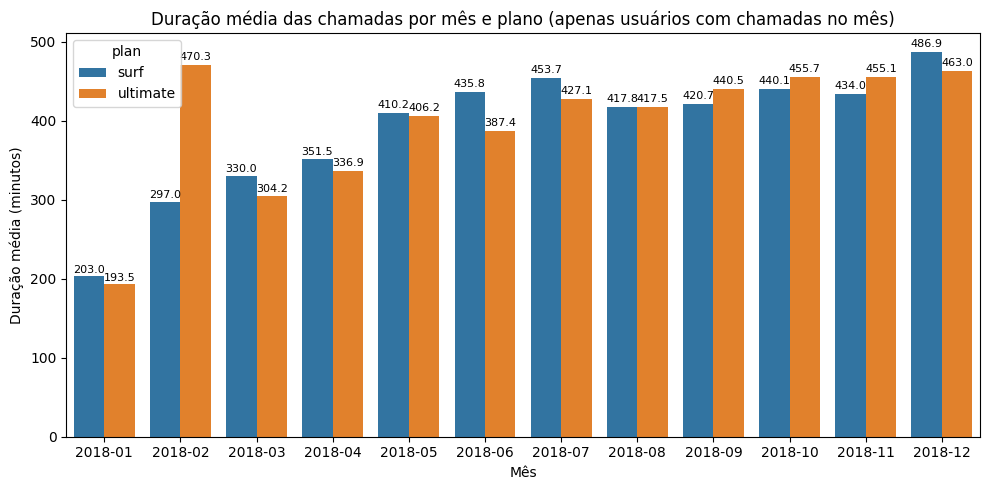

In [44]:
# Compare a duração média das chamadas de cada plano para cada mês. Crie um gráfico de barras para visualizar o resultado.

# Criando um DF de resumo para enxergar as médias agrupada por mês e tipo de plano, trazendo o tamanho das amostras
df_merged_with_calls = df_merged[df_merged['total_duration']>0]
resumo_call_duration_with_calls = pd.pivot_table(df_merged_with_calls, values=['total_duration'], index=['month'], columns=['plan'], aggfunc=['mean', 'count']).round(1)

display(resumo_call_duration_with_calls)

# Plotando gráfico de barras da duração de chamads por mês e plano
bar_plot_planos(df_dados=resumo_call_duration_with_calls, x='month', y='avg_call_duration', hue='plan', 
                column_of_interest='total_duration',
                title='Duração média das chamadas por mês e plano (apenas usuários com chamadas no mês)',
                xlabel='Mês', ylabel='Duração média (minutos)')

,plan,avg_call_duraiton
1,surf,437.0
2,ultimate,435.1


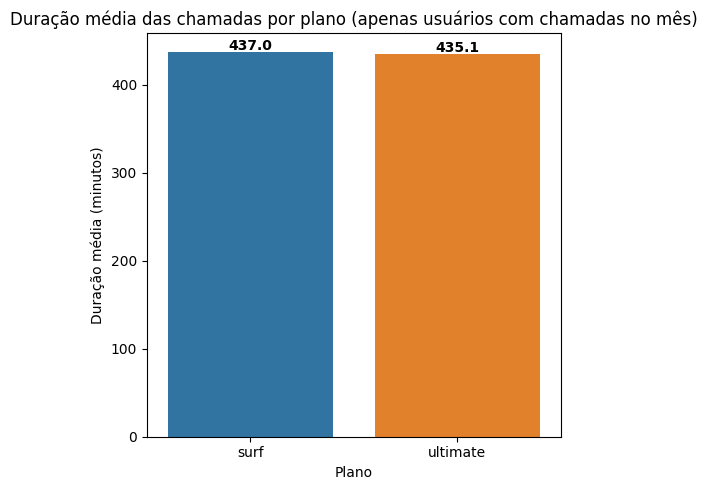

In [45]:
# Calculando a média total ao longo de todos meses:

bar_plot_planos_geral(df_base=df_merged_with_calls, metric_column='total_duration', y_name='avg_call_duraiton', 
                      title='Duração média das chamadas por plano (apenas usuários com chamadas no mês)',
                      xlabel='Plano', ylabel='Duração média (minutos)', pad_datalabel_height=2)

**Resumo sobre as Médias da Ligações**

- A média do tempo de ligação entre os planos é muito similar quando no olhamos no total.
- Quando olhamos mês a mês, há variações, em alguns meses o plano "surf" tem uma média maior e em outros meses o plano "ultimate" tem uma média maior. 
    - Porém com exceção de Fev/18, as médias não se diferem muito
- No final, essa diferença não parece ser relevante, até porque a média de ambos os planos, estão abaixo do limite do plano mais básico (Plano "surf" com 500 minutos mensais). Portanto olhando pela média, nenhum dos planos parece gerar muito dinheiro através de minutos de ligações mensais
    - Porém precisaremos ver a distribuição dos casos, pois a média não mostra de fato quantos usuários estão gerando receita extra devido ao uso de ligações

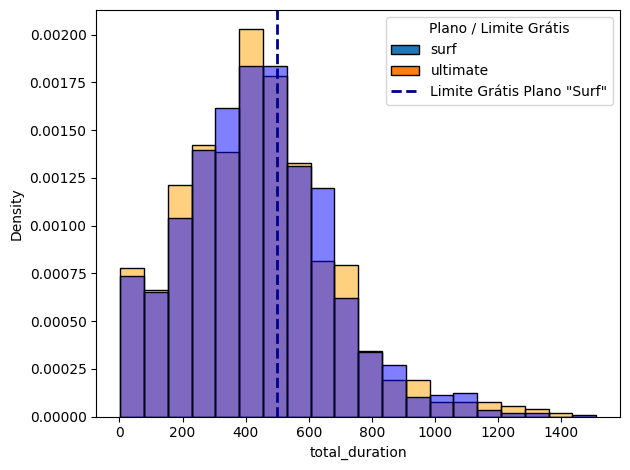

In [46]:
# Plotando histograma de minutos de ligação

histograma_planos(df_dados=df_merged_with_calls, x_hist='total_duration', hue='plan', axv=500,
                  axv_label='Limite Grátis Plano "Surf"', axv2=None, axv2_label=None, title_labels='Plano / Limite Grátis',
                  hue_order=['surf', 'ultimate'])

Calculando média, variância e desvio padrão da quantidade de ligação por planos

In [47]:
# Calcule a média e a variância da duração mensal das chamadas

duracao_surf = df_merged_with_calls[df_merged_with_calls['plan']=='surf']['total_duration']
duracao_ultimate = df_merged_with_calls[df_merged_with_calls['plan']=='ultimate']['total_duration']

avg_surf = duracao_surf.mean().round(1)
avg_ultimate = duracao_ultimate.mean().round(1)

var_surf = np.var(duracao_surf).round(1)
var_ultimate = np.var(duracao_ultimate).round(1)

print(f'Plano Surf --> Média = {avg_surf} | Variância = {var_surf}')
print(f'Plano Ultimate --> Média = {avg_ultimate} | Variância = {var_ultimate}')

Plano Surf --> Média = 437.0 | Variância = 52777.3
Plano Ultimate --> Média = 435.1 | Variância = 56510.3


In [48]:
df_stats = df_merged_with_calls.groupby('plan')['total_duration'].agg(['mean', 'var', 'std']).reset_index().round(1)
display(df_stats)

,plan,mean,var,std
0,surf,437.0,52812.1,229.8
1,ultimate,435.1,56591.1,237.9


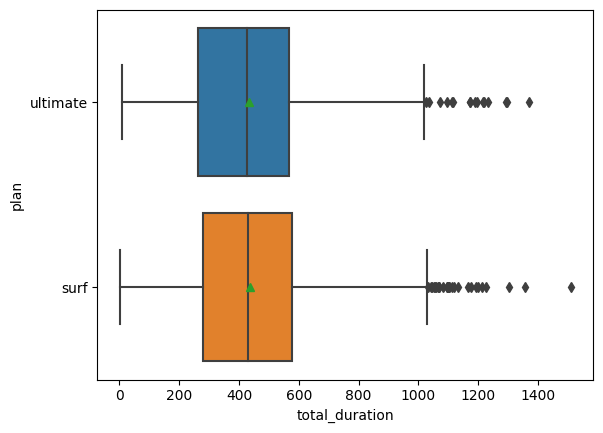

In [49]:
# Faça um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

sns.boxplot(data=df_merged_with_calls, y='plan', x='total_duration', showmeans=True)
plt.show()


Resumo Chamadas

- Ambas as médias são muito similares, com o plano "surf" que é mais básico, tendo uma média levemente acima;
- Ambas as variâncias também são similares, porém o plano "ultimate" tem uma variância um pouco superior, com alguns clientes com muitos minutos de durações;
- Há diversos casos de clientes de ambos os planos com mais de 500 minutos de ligação no mês, que é a quantia inclusa do plano "Surf", o que indica que esses clientes gerariam receita extra (3 centavos por minuto adicional)
    - Porém não há casos de clientes que ultrapassagem o limite de 3000 minutos por mês, que é do plano 'ultimate'. É como se esse plano tivesse minutos ilimitados na prática
    
--> Há diferença entre os planos entre o comportamento de chamadas, mas é uma diferença muito pequena. Porém ainda é provável que a diferença de comportamento dos planos esteja no uso de mensagens ou internet, que será verificado em seguida

### Mensagens

In [50]:
df_resumo_messages = pd.pivot_table(df_merged, values=['messages_count'], index=['month'], columns=['plan'], aggfunc=['mean', 'count']).round(1)
display(df_resumo_messages)

mean                   count         
        messages_count          messages_count         
plan              surf ultimate           surf ultimate
month                                                  
2018-01            0.7      3.3             30       19
2018-02            1.8      4.9             60       31
2018-03            3.9      5.9             90       41
2018-04            7.0      8.9            124       52
2018-05           12.4     14.3            149       65
2018-06           13.6     15.9            181       87
2018-07           16.0     19.6            205       99
2018-08           19.8     23.6            235      115
2018-09           23.4     25.8            255      125
2018-10           27.6     30.9            284      134
2018-11           29.6     32.9            304      148
2018-12           36.2     42.9            325      155

Novamente, assim como no caso das ligações, parece haver muitos casos de clientes registrados sem mensagens no mês. 
Para contornar isso, filtraremos apenas clientes com alguma mensagem no mês

mean                   count         
        messages_count          messages_count         
plan              surf ultimate           surf ultimate
month                                                  
2018-01           21.0     20.7              1        3
2018-02           21.6     25.2              5        6
2018-03           21.9     34.7             16        7
2018-04           24.2     28.9             36       16
2018-05           33.0     44.3             56       21
2018-06           33.6     36.3             73       38
2018-07           35.9     41.2             91       47
2018-08           37.6     48.5            124       56
2018-09           39.5     46.7            151       69
2018-10           42.2     47.0            186       88
2018-11           40.9     48.1            220      101
2018-12           48.2     54.5            244      122

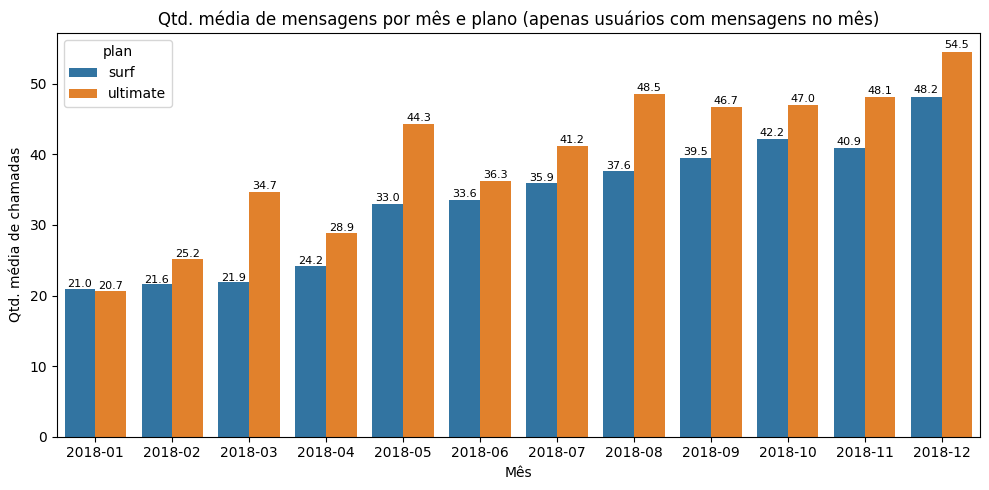

In [51]:
# Compare o número de mensagens que os usuários de cada plano costumam enviar a cada mês


# Criando um DF de resumo para enxergar as médias agrupada por mês e tipo de plano, trazendo o tamanho das amostras
df_merged_with_messages = df_merged[df_merged['messages_count']>0]
df_resumo_messages = pd.pivot_table(df_merged_with_messages, values=['messages_count'], index=['month'], columns=['plan'], aggfunc=['mean', 'count']).round(1)

display(df_resumo_messages)


bar_plot_planos(df_dados=df_resumo_messages, x='month', y='avg_message_count', hue='plan', 
                column_of_interest='messages_count',
                title='Qtd. média de mensagens por mês e plano (apenas usuários com mensagens no mês)',
                xlabel='Mês', ylabel='Qtd. média de chamadas', pad_datalabel_height=0)


,plan,avg_message_count
1,surf,40.0
2,ultimate,46.6


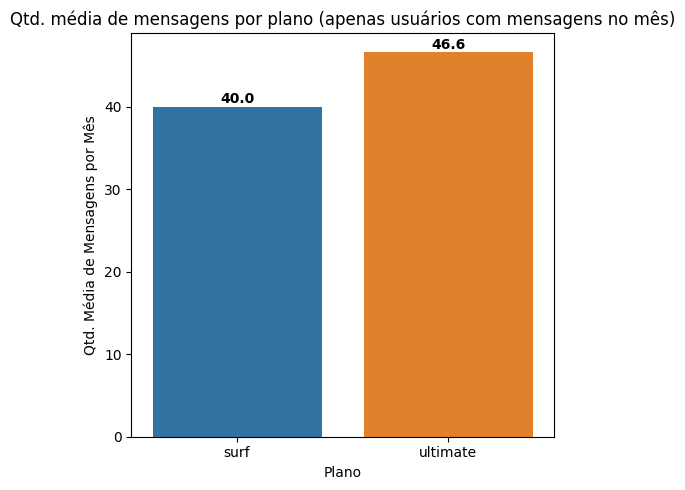

In [52]:
# Calculando a média total ao longo de todos meses:

bar_plot_planos_geral(df_base=df_merged_with_messages, metric_column='messages_count', y_name='avg_message_count', 
                      title='Qtd. média de mensagens por plano (apenas usuários com mensagens no mês)',
                      xlabel='Plano', ylabel='Qtd. Média de Mensagens por Mês', pad_datalabel_height=0.4)

A média de mensagens do plano 'ultimate' é claramente maior que a do plano 'surf' (16,5% maior no ano) e se enxerga isso em todos os meses (com exceção de janeiro).

Ainda sim, a média de ambos é abaixo de 50 mensagens/mês, o que ainda não geraria gasto adicional no plano "surf". Porém ainda precisamos entender a distribuição

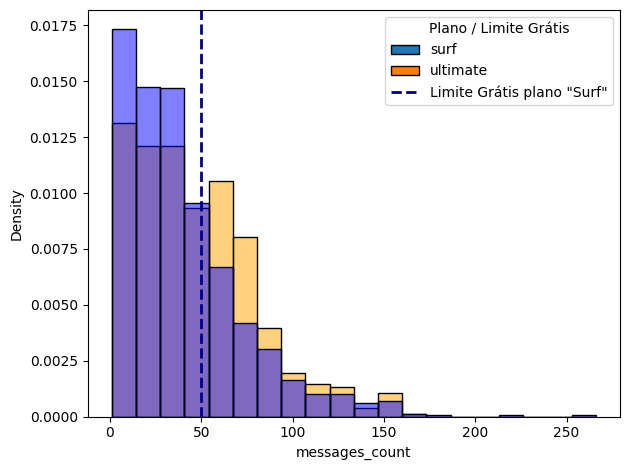

In [53]:
# Construindo um histrograma para entender a distribuição no uso de mensagens em cada plano

histograma_planos(df_dados=df_merged_with_messages, x_hist='messages_count', hue='plan', axv=50,
                  axv_label='Limite Grátis plano "Surf"', axv2=None, axv2_label='Limite Grátis planos "Ultimate"',
                  title_labels='Plano / Limite Grátis', hue_order=['surf', 'ultimate'])


In [54]:
# Vendo as médias e desvios de cada plano:
df_stats_msgs = df_merged_with_messages.groupby('plan')['messages_count'].agg(['mean', 'var', 'std']).reset_index().round(1)
display(df_stats_msgs)

,plan,mean,var,std
0,surf,40.0,1099.1,33.2
1,ultimate,46.6,1090.4,33.0


A variância e desvio padrão de ambos os planos são muito similares, a distinção é de fato a média de mensagens, que é uns 16,5% mais alta para o plano 'Ultimate'

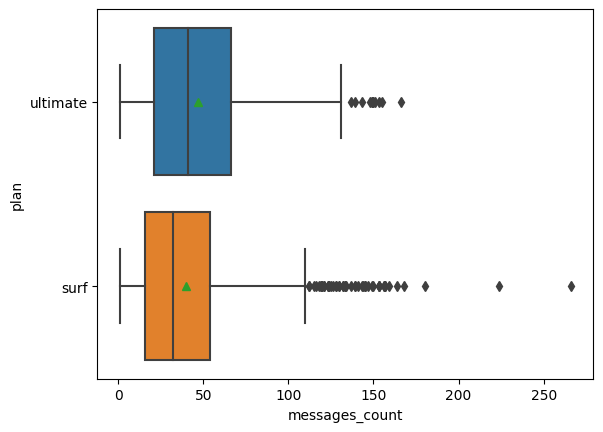

In [55]:
sns.boxplot(data=df_merged_with_messages, y='plan', x='messages_count', showmeans=True)
plt.show()


-------------------------------------------------------------------------------------------------------------------------------
**Comparação entre os Planos:**
- A média de mensagens do plano 'Ultimate' é maior do que a do plano 'Surf';
- A variância e desvio padrão de ambos são muitos similares
- O plano 'Surf' parece ter mais outliers, com alguns clientes em alguns meses com um volume de mensagens muito acima da média e acima do Q3, esses clientes devem gerar bastante receita adicional de mensagens, visto que eles são do plano com um limite de 50 mensagens grátis/mês;

**Comentário do histograma:**
- Vemos que ambos os planos possuem bastante casos de clientes com minutos acima do limiar grátis de 50 mensagens do plano 'Surf'
    - Temos que a direita da linha vertical de 50 mensagens: Os clientes do plano 'Surf' estão paganado além da taxa base do plano e os clientes do plano 'Ultimate' estão deixando de pagar por escolher aquele plano

### Internet

In [56]:
# Compare a quantidade de tráfego de internet consumido pelos usuários por plano
resumo_internet = pd.pivot_table(df_merged, values=['total_gb'], index=['month'], columns=['plan'], aggfunc=['mean', 'count']).round(1)
display(resumo_internet)

mean             count         
        total_gb          total_gb         
plan        surf ultimate     surf ultimate
month                                      
2018-01      0.3      1.5       30       19
2018-02      1.8      3.9       60       31
2018-03      3.5      5.4       90       41
2018-04      4.9      6.6      124       52
2018-05      7.3      7.5      149       65
2018-06      8.3      8.3      181       87
2018-07     10.0      9.8      205       99
2018-08     11.6     10.9      235      115
2018-09     12.7     11.6      255      125
2018-10     14.3     13.9      284      134
2018-11     14.9     14.4      304      148
2018-12     17.1     17.3      325      155

Novamente vimos que o uso cresce muito ao longo do meses, devido ao impacto de clientes com 0 uso dentro do mês. 
Filtratei no df apenas clientes com algum uso de internet por mês para isolar esse impacto

mean             count         
        total_gb          total_gb         
plan        surf ultimate     surf ultimate
month                                      
2018-01      5.0      7.2        2        4
2018-02     12.2     17.3        9        7
2018-03     13.6     18.4       23       12
2018-04     12.5     16.3       49       21
2018-05     14.3     16.9       76       29
2018-06     15.8     15.4       95       47
2018-07     17.0     16.5      120       59
2018-08     17.2     17.8      159       70
2018-09     16.8     17.2      193       84
2018-10     17.6     17.9      230      104
2018-11     16.6     17.2      274      124
2018-12     18.3     18.4      303      146

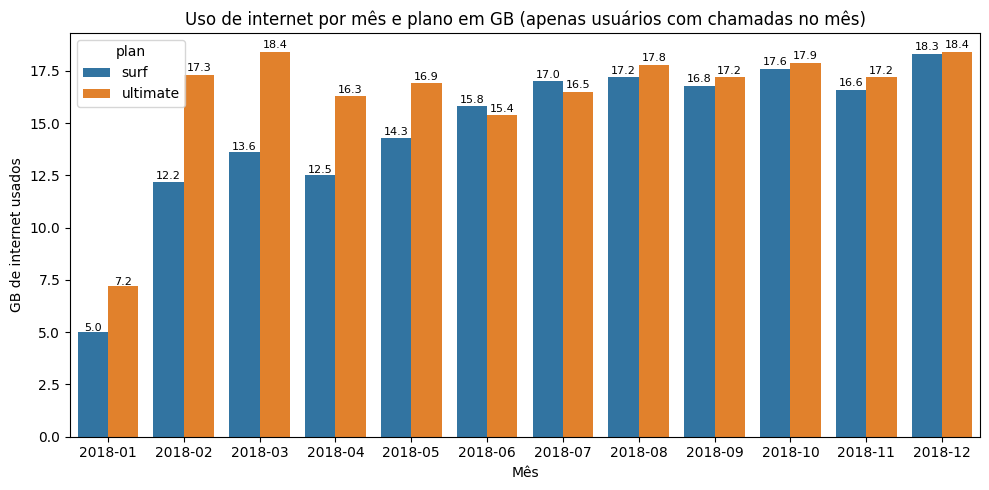

In [57]:
df_merged_with_internet = df_merged[df_merged['total_gb']>0]
resumo_internet_with_usage = pd.pivot_table(df_merged_with_internet, values=['total_gb'], index=['month'], columns=['plan'], aggfunc=['mean', 'count']).round(1)

display(resumo_internet_with_usage)

# Plotando gráfico de barras da duração de chamads por mês e plano
bar_plot_planos(df_dados=resumo_internet_with_usage, x='month', y='avg_internet_usage', hue='plan', 
                column_of_interest='total_gb',
                title='Uso de internet por mês e plano em GB (apenas usuários com chamadas no mês)',
                xlabel='Mês', ylabel='GB de internet usados', pad_datalabel_height=0)


,plan,avg_internet_usage
1,surf,16.8
2,ultimate,17.4


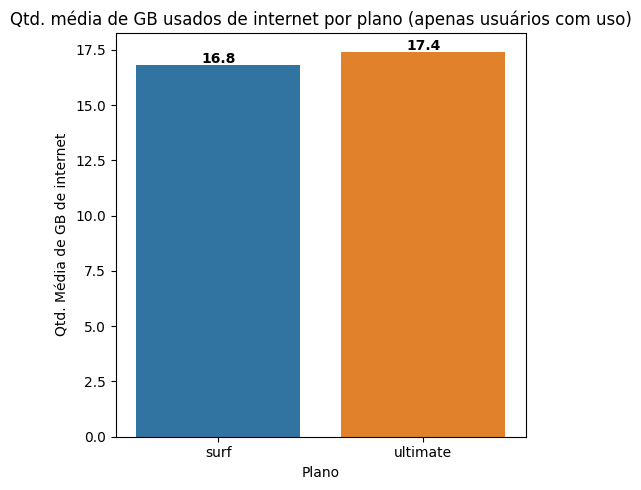

In [58]:
# Calculando a média total ao longo de todos meses:

bar_plot_planos_geral(df_base=df_merged_with_internet, metric_column='total_gb', y_name='avg_internet_usage', 
                      title='Qtd. média de GB usados de internet por plano (apenas usuários com uso)',
                      xlabel='Plano', ylabel='Qtd. Média de GB de internet', pad_datalabel_height=0.1)

- O uso de internet do plano 'Ultimate' é levemente superior (+3,5%) ao plano 'Surf"
- A média do uso de internet de ambos os planos é superior à 15GB, que é o limiar de consumo grátis do plano 'Surf', o que dá a entender que há bastante receita adicional proveninente do consumo de internet

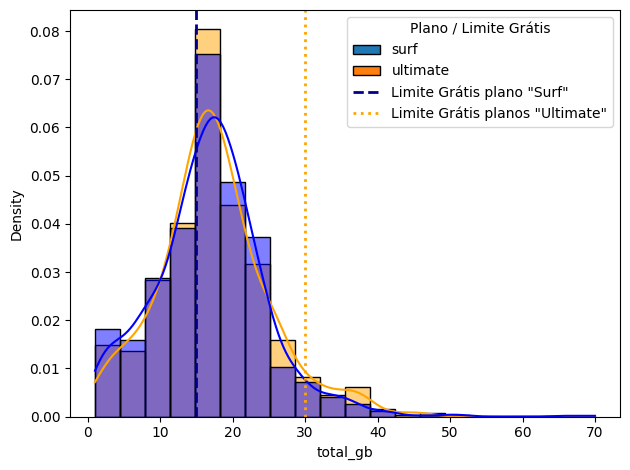

,plan,mean,var,std
0,surf,16.8,59.3,7.7
1,ultimate,17.4,59.0,7.7


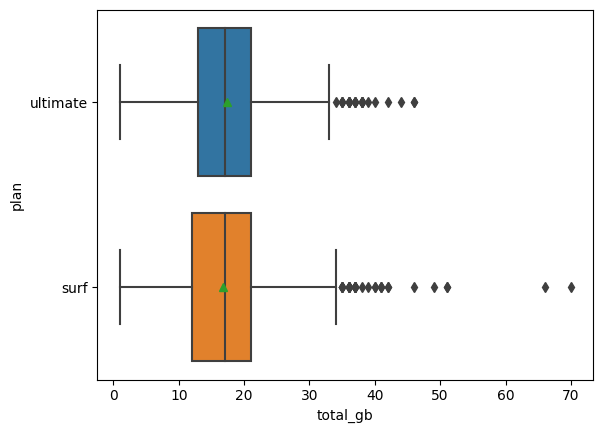

In [59]:
# Construindo um histrograma para entender a distribuição no uso de mensagens em cada plano

histograma_planos(df_dados=df_merged_with_internet, x_hist='total_gb', hue='plan', axv=15,
                  axv_label='Limite Grátis plano "Surf"', axv2=30, axv2_label='Limite Grátis planos "Ultimate"',
                  title_labels='Plano / Limite Grátis', hue_order=['surf', 'ultimate'], kde=True)

# Vendo as médias e desvios de cada plano:
df_stats_internet = df_merged_with_internet.groupby('plan')['total_gb'].agg(['mean', 'var', 'std']).reset_index().round(1)
display(df_stats_internet)


# Plotando o boxplot:
sns.boxplot(data=df_merged_with_internet, y='plan', x='total_gb', showmeans=True)
plt.show()



-------------------------------------------------------------------------------------------------------------------------------
- As médias e desvio padrão de cada plano são muito similares para o consumo de internet;
- Quando olhamos o histograma, vemos que o plano 'ultimate' possui maior concentração para alguns valores mais altos, o que acaba puxando a média um pouco para cima
- No histograma, percebemos que há muitos casos de clientes acima do limiar "grátis" de cada plano, o que a entender que esse serviço gera bastante receita, em ambos os planos
    - No caso do plano 'Ultimate' é uma minoria dos clientes que ultrapassagem esse limite;
    - Porém no plano 'Surf', a maioria dos clientes está acima do limiar de 15 GB de consumo.
- No boxplot vemos que o plano 'Surf' possui mais outliers para direita, com consumos muito elevados, o que devem ter gerado bastante receita.

Dado que o plano 'Ultimate' é um plano basalmente mais caro, com limites muito superiores ao plano 'Surf' nos serviços, ele não demonstrou tanta diferente frente ao plano 'Surf' quanto o esperado, o comportamento desses clientes não está tão distante do comportamento dos clientes do plano 'Surf'.

Isso dá a entender que ou os clientes do plano 'Surf' poderiam aderir ao plano 'Ultimate' e economizar, ou os clientes do plano 'Surf' não estão justificando o plano contratado de acordo com os hábitos de usos dos serviços.


## Receita

mean            count         
        revenue          revenue         
plan       surf ultimate    surf ultimate
month                                    
2018-01    20.0     70.0      30       19
2018-02    22.2     70.0      60       31
2018-03    26.6     71.4      90       41
2018-04    28.4     71.2     124       52
2018-05    34.3     70.3     149       65
2018-06    35.7     70.9     181       87
2018-07    45.2     71.1     205       99
2018-08    50.3     71.8     235      115
2018-09    49.1     71.4     255      125
2018-10    57.4     71.8     284      134
2018-11    54.7     71.5     304      148
2018-12    67.2     73.2     325      155

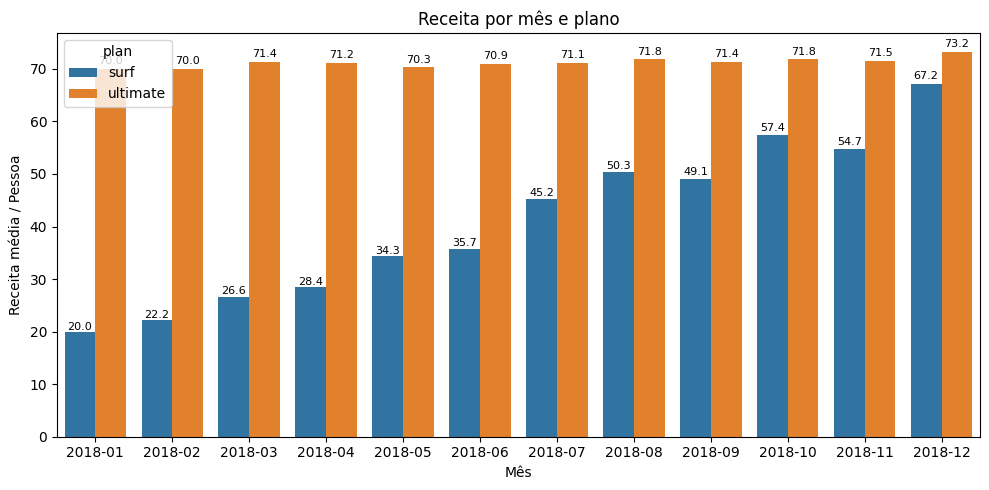

In [60]:
# Vendo Receita Média por Pessoa por Mês para cada plano

# Criando um DF de resumo para enxergar as médias agrupada por mês e tipo de plano, trazendo o tamanho das amostras
df_merged_with_revenue = df_merged[df_merged['revenue']>0]
resumo_revenue = pd.pivot_table(df_merged_with_revenue, values=['revenue'], index=['month'], columns=['plan'], aggfunc=['mean', 'count']).round(1)

display(resumo_revenue)

# Plotando gráfico de barras da duração de chamads por mês e plano
bar_plot_planos(df_dados=resumo_revenue, x='month', y='avg_revenue', hue='plan', 
                column_of_interest='revenue',
                title='Receita por mês e plano',
                xlabel='Mês', ylabel='Receita média / Pessoa', pad_datalabel_height=0.2)

,plan,avg_revenue
1,surf,48.1
2,ultimate,71.6


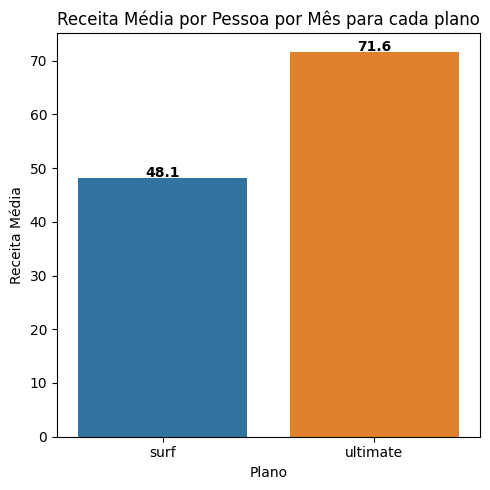

In [61]:
# Vendo Receita Média por Pessoa por Mês para cada plano no total do ano

bar_plot_planos_geral(df_base=df_merged_with_revenue, metric_column='revenue', y_name='avg_revenue', 
                      title='Receita Média por Pessoa por Mês para cada plano',
                      xlabel='Plano', ylabel='Receita Média', pad_datalabel_height=0.2)

1) Fazer os mesmos gráficos da demais métricas
2) Olhar para a métrica de receita adicional, e também olhar o incremental de cada serviço nos planos para entender o impacto
3) 

In [62]:
# df_merged_with_revenue[(df_merged_with_revenue['plan']=='ultimate')&(df_merged_with_revenue['revenue']<70)]
len(df_merged_with_revenue)
len(df_merged_with_revenue[df_merged_with_revenue['plan']=='surf'])

2242

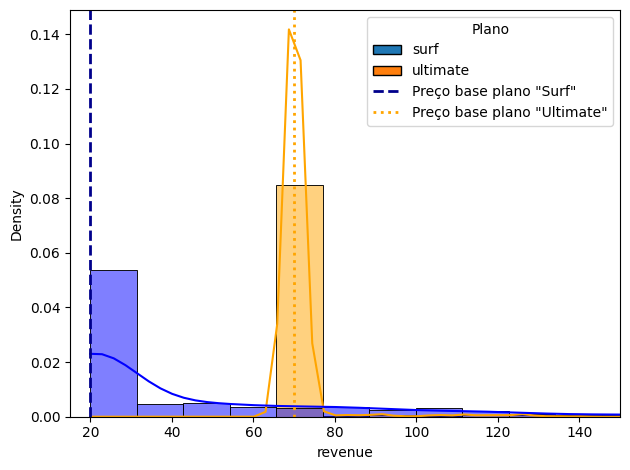

,plan,mean,var,std
0,surf,48.1,2468.4,49.7
1,ultimate,71.6,88.4,9.4


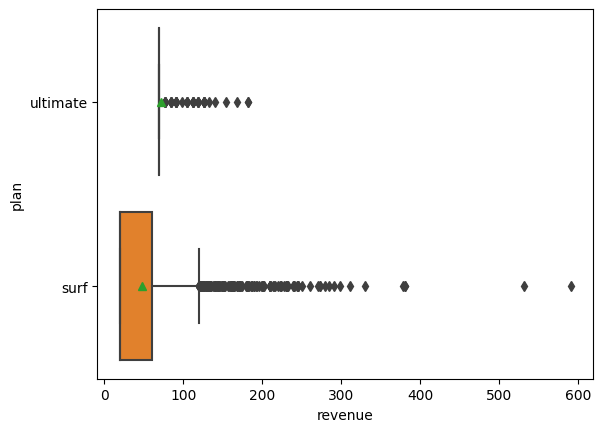

In [63]:
# Histograma de receita por plano

# bins_param = [20,25,30,35,40,45,50,55,60,70,75,80,85,90,110,120,130,140,150,200]
bins_param = 50

histograma_planos(df_dados=df_merged_with_revenue, x_hist='revenue', hue='plan', axv=20,
                  axv_label='Preço base plano "Surf"', axv2=70, axv2_label='Preço base plano "Ultimate"',
                  title_labels='Plano', hue_order=['surf', 'ultimate'], kde=True
                  ,bins_param=bins_param,xmin=15, xmax=150)

# Vendo as médias e desvios de cada plano:
df_stats_revenue = df_merged_with_revenue.groupby('plan')['revenue'].agg(['mean', 'var', 'std']).reset_index().round(1)
display(df_stats_revenue)


# Plotando o boxplot:
sns.boxplot(data=df_merged_with_revenue, y='plan', x='revenue', showmeans=True)
plt.show()

Ficou complicado de enxergar muito bem o histograma, visto que há uma concentração muito grande de clientes com revenue igual ao custo base de cada plano, e poucos casos espalhados em receitas maiores. 
Portanto irei plotar o gráfico de KDE, para ver a densidade de distribuição

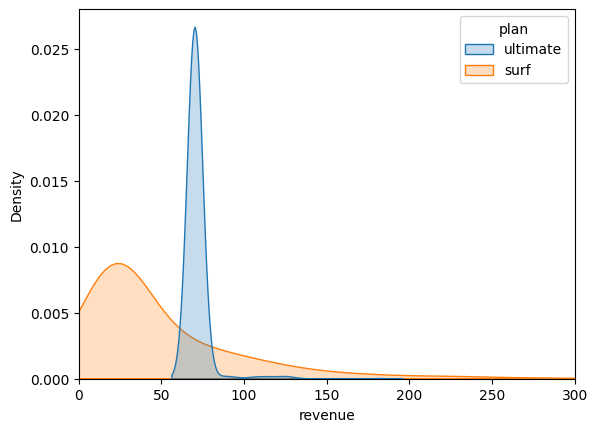

In [64]:
sns.kdeplot(data=df_merged_with_revenue, x='revenue', hue='plan', fill=True, bw_adjust=2)
plt.xlim(0, 300)
# sns.kdeplot(data=df_merged_with_revenue, x='revenue', hue='plan', fill=True, common_norm=False)

plt.show()

Nota-se que o plano Ultimate possui uma concentração maior em torno da receita base do plano ($ 70), possui pouca variabilidade. Isso nota-se também pela tabela de estatística mostrada anteriormente, onde o desvio padrão do plano "surf" é de 49,7 e o do plano "ultimate" é de 9,4.

Apesar dos clientes com mais receita serem do plano Surf, o plano Ultimate possui ainda sim uma média maior de receita, visto que há uma concentração em torno da receita de \$ 70, enquanto a média do plano Surf ainda continua abaixo disso

<AxesSubplot:xlabel='total_gb', ylabel='revenue'>

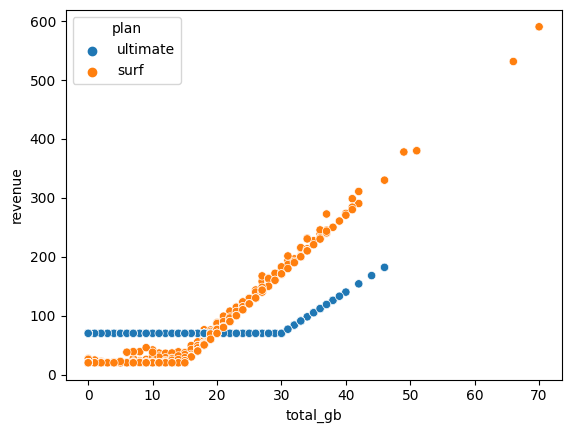

In [65]:
sns.scatterplot(data=df_merged_with_revenue, x='total_gb' ,y='revenue', hue='plan')
# sns.scatterplot(data=df_merged_with_revenue, x='total_duration' ,y='revenue', hue='plan')

In [66]:
# Olhando em média a receita total de cada plano, assim como as receitas adicionais por serviço
df_merged_with_revenue[['plan', 'revenue', 'message_revenue', 'calls_revenue', 'internet_revenue', 'additional_revenue']].groupby(by=['plan']).mean().round(1)

,revenue,message_revenue,calls_revenue,internet_revenue,additional_revenue
plan,,,,,
surf,48.1,0.1,1.3,26.6,28.1
ultimate,71.6,0.0,0.0,1.6,1.6



---------------------------------------------------------------------------------------

1. O plano Ultimate traz na média 48,8% mais receita do que o plano Surf (71.6 vs. 48.1);
2. O plano Surf possui muito mais variabilidade, com a sua distribuição de receita se espalhando para receitas muito acima das amostras do plano Ultimate, alguns dos clientes mais rentáveis. 
    - A média do plano Surf é consideravelmente acima do seu custo base de \$ 20, agregando muita receita adicional pelos serviços utilizados
    - Enquanto a média do plano Ultimate é praticamente a mesma de seu custo base \$ 70, agregando pouca receita adicional pelos serviços utilizados
3. Nota-se que a receita adicional vem quase totalmente do serviço de internet, enquanto as linhas de mensagem ou ligações, são pouco relevantes em termos de receita. 
    
    
O plano Surf traz muita receita adicional pelo uso de serviços acima do limite do plano, porém não o suficiente para cobrir o gap do custo base entre os planos, sendo assim, o plano Ultimate ainda mais rentável, na média, para a empresa. 

## Teste hipóteses estatísticas

[Teste a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes.]

Hipótese Nula (H0) - As médias de receita de ambos os planos são iguais  


$\alpha$ = 0.05

In [67]:
# Teste as hipóteses
from scipy import stats as st

alpha = 0.05

revenues_surf = df_merged_with_revenue[df_merged_with_revenue['plan']=='surf']['revenue'].tolist()
revenues_ultimate = df_merged_with_revenue[df_merged_with_revenue['plan']=='ultimate']['revenue'].tolist()

results = st.ttest_ind(revenues_surf, revenues_ultimate)

print(f'valor-p: {results.pvalue} |  Estatística t: {results.statistic.round(2)}') # extraindo o valor-p

if results.pvalue < alpha: # comparando o valor-p com o limiar
    print("Rejeitamos a hipótese nula")
else:
    print("Não podemos rejeitar a hipótese nula")

valor-p: 2.335027843149218e-51 |  Estatística t: -15.34
Rejeitamos a hipótese nula


Podemos rejeitar a hipótese nula, ou seja, as médias são de fato diferentes.

[Teste a hipótese de que a receita média dos usuários da área de NY-NJ difere dos usuários das demais regiões.]

Hipótese Nula (H$_0$): As médias de receita entre a região de NY e NY-NJ e as demais regiões são iguais  

Hipótese Alternativa (H$_1$): As médias são diferentes  

$\alpha$ = 0.05

In [68]:
# Preparando os dados de cada região
df_ny_nj = df_merged_with_revenue[(df_merged_with_revenue['city'].str.contains('NY MSA', case=True, na=False))
                               |(df_merged_with_revenue['city'].str.contains('NY-NJ', case=True, na=False))]

df_rest = df_merged_with_revenue[~((df_merged_with_revenue['city'].str.contains('NY MSA', case=True, na=False))
                               |(df_merged_with_revenue['city'].str.contains('NY-NJ', case=True, na=False)))]

# Receitas
revenue_ny_nj = df_ny_nj['revenue'].tolist()
revenue_rest = df_rest['revenue'].tolist()



In [69]:
# Teste as hipóteses

results = st.ttest_ind(revenue_ny_nj, revenue_rest)

print(f'valor-p: {results.pvalue} |  Estatística t: {results.statistic.round(2)}') # extraindo o valor-p

if results.pvalue < alpha: # comparando o valor-p com o limiar
    print("Rejeitamos a hipótese nula")
else:
    print("Não podemos rejeitar a hipótese nula")

valor-p: 0.06012375670561324 |  Estatística t: -1.88
Não podemos rejeitar a hipótese nula


Tivemos um alpha > 0.05, portanto não podemos rejeitar a hipótese nula de que as médias são diferentes.  
Porém nesse teste, não consideramos o efeito do plano, que se provou ser muito relevante. Para um teste mais assertivo, irei separar os planos, além das regiões

In [70]:
# Vendo as médias e desvios de cada plano p/ cada região:
df_stats_nynj = df_ny_nj.groupby('plan')['revenue'].agg(['mean', 'var', 'std']).reset_index().round(1)
display(df_stats_nynj)

df_stats_rest = df_rest.groupby('plan')['revenue'].agg(['mean', 'var', 'std']).reset_index().round(1)
display(df_stats_rest)

,plan,mean,var,std
0,surf,47.5,1965.2,44.3
1,ultimate,72.7,115.4,10.7


,plan,mean,var,std
0,surf,48.2,2601.5,51.0
1,ultimate,71.4,84.9,9.2


In [71]:
# comparando receita do plano surf entre regiões
revenue_ny_nj_surf = df_ny_nj[df_ny_nj['plan']=='surf']['revenue'].tolist()
revenue_rest_surf = df_rest[df_rest['plan']=='surf']['revenue'].tolist()

results_surf = st.ttest_ind(revenue_ny_nj_surf, revenue_rest_surf)
print(f'Surf) valor-p: {results_surf.pvalue} |  Estatística t: {results_surf.statistic.round(2)}') # extraindo o valor-p
if results_surf.pvalue < alpha: # comparando o valor-p com o limiar
    print("Rejeitamos a hipótese nula (surf)")
else:
    print("Não podemos rejeitar a hipótese nula (surf)")


# comparando receita do plano ultimate entre regiões
revenue_ny_nj_ultimate = df_ny_nj[df_ny_nj['plan']=='ultimate']['revenue'].tolist()
revenue_rest_ultimate = df_rest[df_rest['plan']=='ultimate']['revenue'].tolist()

results_ultimate = st.ttest_ind(revenue_ny_nj_ultimate, revenue_rest_ultimate)
print(f'\nUltimate) valor-p: {results_ultimate.pvalue} |  Estatística t: {results_ultimate.statistic.round(2)}') # extraindo o valor-p
if results_ultimate.pvalue < alpha: # comparando o valor-p com o limiar
    print("Rejeitamos a hipótese nula (Ultimate)")
else:
    print("Não podemos rejeitar a hipótese nula (Ultimate)")


Surf) valor-p: 0.7685737911780778 |  Estatística t: -0.29
Não podemos rejeitar a hipótese nula (surf)

Ultimate) valor-p: 0.1698203795415254 |  Estatística t: 1.37
Não podemos rejeitar a hipótese nula (Ultimate)


No caso de comparar os mesmo planos entre as diferentes regiões, o alpha foi ainda maior. Portanto não podemos rejeitar a hipótese nula e afirmar que as médias são diferentes. 

<br>
<b>Refazendo o teste, agora separando apenas entre a reigão NY-NJ, considerando as regiões de "NY" como parte do "resto", separado de NY-NJ. </b>

In [72]:
# Preparando os dados de cada região --> 
df_ny_nj2 = df_merged_with_revenue[df_merged_with_revenue['city'].str.contains('NY-NJ', case=True, na=False)]

df_rest2 = df_merged_with_revenue[~df_merged_with_revenue['city'].str.contains('NY-NJ', case=True, na=False)]

# Receitas
revenue_ny_nj2 = df_ny_nj2['revenue'].tolist()
revenue_rest2 = df_rest2['revenue'].tolist()


# comparando receita do plano surf entre regiões
revenue_ny_nj_surf2 = df_ny_nj2[df_ny_nj2['plan']=='surf']['revenue'].tolist()
revenue_rest_surf2 = df_rest2[df_rest2['plan']=='surf']['revenue'].tolist()

results_surf2 = st.ttest_ind(revenue_ny_nj_surf2, revenue_rest_surf2)
print(f'Surf) valor-p: {results_surf2.pvalue} |  Estatística t: {results_surf2.statistic.round(2)}') # extraindo o valor-p
if results_surf2.pvalue < alpha: # comparando o valor-p com o limiar
    print("Rejeitamos a hipótese nula (surf)")
else:
    print("Não podemos rejeitar a hipótese nula (surf)")


# comparando receita do plano ultimate entre regiões
revenue_ny_nj_ultimate2 = df_ny_nj2[df_ny_nj2['plan']=='ultimate']['revenue'].tolist()
revenue_rest_ultimate2 = df_rest2[df_rest2['plan']=='ultimate']['revenue'].tolist()

results_ultimate2 = st.ttest_ind(revenue_ny_nj_ultimate2, revenue_rest_ultimate2)
print(f'\nUltimate) valor-p: {results_ultimate2.pvalue} |  Estatística t: {results_ultimate2.statistic.round(2)}') # extraindo o valor-p
if results_ultimate2.pvalue < alpha: # comparando o valor-p com o limiar
    print("Rejeitamos a hipótese nula (Ultimate)")
else:
    print("Não podemos rejeitar a hipótese nula (Ultimate)")

Surf) valor-p: 0.4561996601308985 |  Estatística t: -0.75
Não podemos rejeitar a hipótese nula (surf)

Ultimate) valor-p: 0.1698203795415254 |  Estatística t: 1.37
Não podemos rejeitar a hipótese nula (Ultimate)


## Conclusão geral


----------------------------------------------------------------------------------------------------------------------------

**Conclusões**
- Em termos de receita, foi provado que o plano Ultimate traz mais receita que o plano Surf; <br><br>

- Por ter um limite grátis menor no plano Surf, ele acabou gerando mais receita incremental proveniente dos serviços (28,1 por usuário por mês em média). Porém essa receita adicional não foi o suficiente para cobrir o gap da receita base entre os planos, ficando ainda menos rentável que o Ultimate;
    - Os serviços de mensagens e ligações não geram receitas adicionais muito relevantes, a maior parte da receita adicional vem do serviço de internet. <br><br>

- O comportamento do usuários em termos de consumo de internet foram similares entre os planos, com o plano Ultimate tendo uma média de consumo de internet levemente superior. <br><br>

- Não pode-se provar através de teste estatísticos, que há diferença de receita entre as regiões de NY-NJ e demais regiões. E olhando as médias entre as regiões, comparando os mesmos planos, elas de fato são similares.

**Recomendação**

Em linhas gerais, <span style="color: darkblue">recomendo mais investimento na divulgação do plano **Ultimate**</span>, que gera consideravelmente mais receita que o plano Surf.  
São muito poucos clientes que possuem um 
 consumo excessivamente elevados para que de fato tragam mais receita do que os clientes do plano Ultimate. Mas na média, não se paga frente ao plano Ultimate.